In [1]:
from sklearn.cluster import KMeans
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio

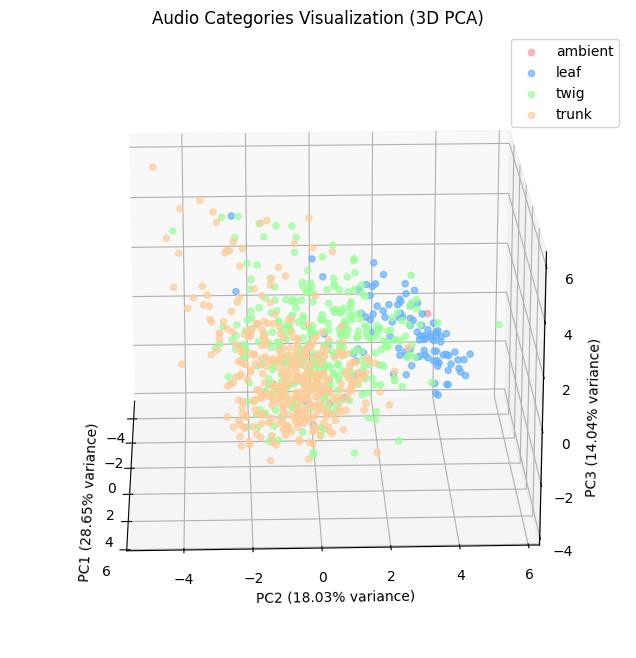


Explained variance ratios:
PC1: 28.65%
PC2: 18.03%
PC3: 14.04%

Mean features by category:

AMBIENT:
RMS: -1.045
ZCR: -1.246
Spectral Centroid: 2.701
Spectral Bandwidth: 3.805
MFCC_1: -3.561
MFCC_2: -2.681

LEAF:
RMS: -0.705
ZCR: 0.450
Spectral Centroid: 1.628
Spectral Bandwidth: 1.635
MFCC_1: -1.341
MFCC_2: -1.267

TWIG:
RMS: -0.058
ZCR: 0.012
Spectral Centroid: -0.040
Spectral Bandwidth: -0.115
MFCC_1: 0.059
MFCC_2: 0.028

TRUNK:
RMS: 0.243
ZCR: -0.129
Spectral Centroid: -0.410
Spectral Bandwidth: -0.350
MFCC_1: 0.319
MFCC_2: 0.323


In [7]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio

# Function to extract features from audio file
def extract_features(audio_path):
    y, sr = librosa.load(audio_path)
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)
    rms = librosa.feature.rms(y=y)[0].mean()
    zcr = librosa.feature.zero_crossing_rate(y=y)[0].mean()
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0].mean()
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0].mean()
    
    # Combine features
    features = np.concatenate([[rms, zcr, spec_cent, spec_bw], mfccs])
    return features

categories = ['ambient', 'leaf', 'twig', 'trunk']
X = []
y = []
filenames = []

for category in categories:
    category_path = os.path.join('./output', category)
    for file in os.listdir(category_path):
        if file.endswith('.wav'):
            file_path = os.path.join(category_path, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(category)
            filenames.append(file)

X = np.array(X)
y = np.array(y)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D plot with animation
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each category with different colors
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for category, color in zip(categories, colors):
    mask = y == category
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2], 
              label=category, alpha=0.7, c=color)

# Add labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('Audio Categories Visualization (3D PCA)')
plt.legend()

# Animation function
def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

# Create animation
anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), 
                    interval=50, blit=True)

# Save as GIF
anim.save('3d_plot_rotation.gif', writer='pillow')

plt.show()

# Print explained variance ratios
print("\nExplained variance ratios:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.2%}")

# Feature analysis
feature_names = ['RMS', 'ZCR', 'Spectral Centroid', 'Spectral Bandwidth'] + [f'MFCC_{i+1}' for i in range(13)]

# Calculate mean features for each category
print("\nMean features by category:")
for category in categories:
    mask = y == category
    category_features = X_scaled[mask]
    mean_features = category_features.mean(axis=0)
    print(f"\n{category.upper()}:")
    for name, value in zip(feature_names[:6], mean_features[:6]): 
        print(f"{name}: {value:.3f}")

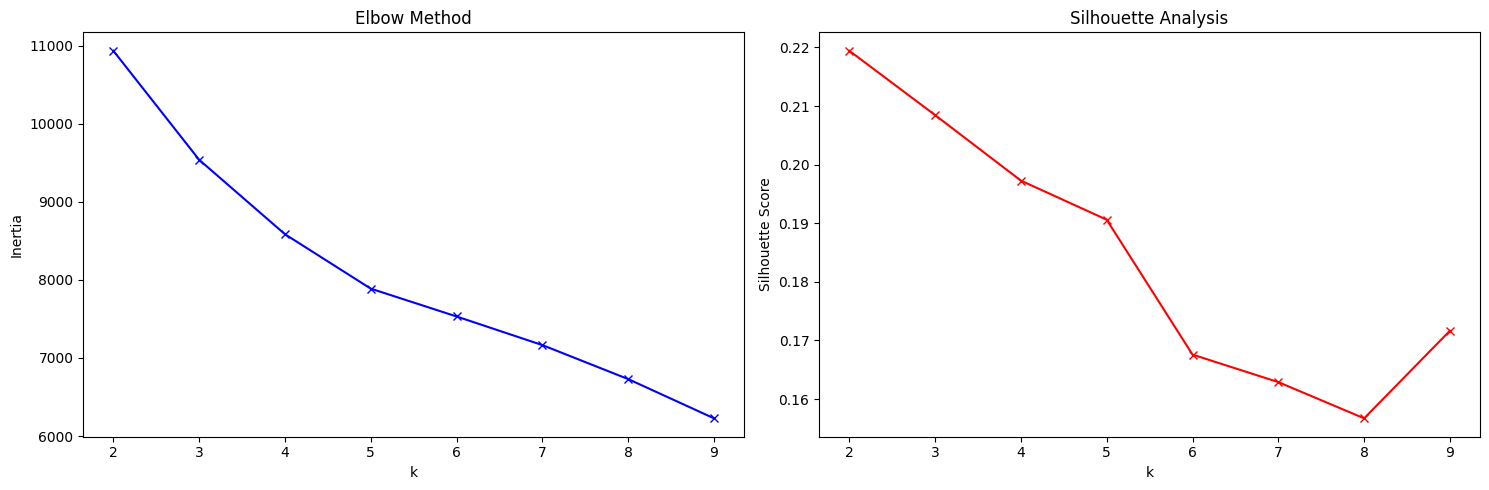

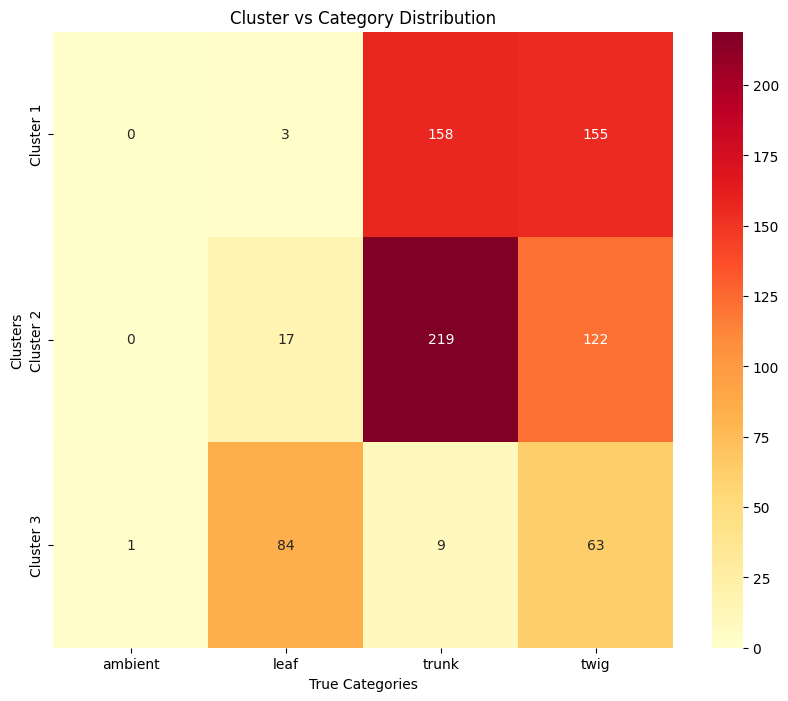


Cluster 1:
Size: 316 samples (38.0% of total)

Category distribution:
ambient: 0 samples (0.0%)
leaf: 3 samples (0.9%)
trunk: 158 samples (50.0%)
twig: 155 samples (49.1%)

Top features at centroid:
MFCC_4: 0.875
ZCR: -0.693
MFCC_3: 0.690
MFCC_10: -0.679
MFCC_6: 0.627

Cluster 2:
Size: 358 samples (43.1% of total)

Category distribution:
ambient: 0 samples (0.0%)
leaf: 17 samples (4.7%)
trunk: 219 samples (61.2%)
twig: 122 samples (34.1%)

Top features at centroid:
MFCC_2: 0.844
MFCC_12: -0.844
MFCC_11: -0.727
MFCC_4: -0.699
MFCC_6: -0.657

Cluster 3:
Size: 157 samples (18.9% of total)

Category distribution:
ambient: 1 samples (0.6%)
leaf: 84 samples (53.5%)
trunk: 9 samples (5.7%)
twig: 63 samples (40.1%)

Top features at centroid:
Spectral Bandwidth: 1.518
Spectral Centroid: 1.407
MFCC_2: -1.222
MFCC_1: -0.873
MFCC_12: 0.754

Overall Clustering Metrics:
Silhouette Score: 0.208
Inertia: 9538.285
Cluster Purity: 0.555


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

true_labels = y
true_labels = y

X_for_clustering = X_scaled

inertias = []
silhouette_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_for_clustering)
    
    inertias.append(kmeans.inertia_)
    
    silhouette_scores.append(silhouette_score(X_for_clustering, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K, inertias, 'bx-')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K, silhouette_scores, 'rx-')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_for_clustering)

categories_unique = np.unique(true_labels)
cluster_category_counts = np.zeros((optimal_k, len(categories_unique)))

for i in range(optimal_k):
    for j, category in enumerate(categories_unique):
        cluster_category_counts[i, j] = np.sum(
            (cluster_labels == i) & (true_labels == category)
        )

plt.figure(figsize=(10, 8))
sns.heatmap(cluster_category_counts, 
            xticklabels=categories_unique,
            yticklabels=[f'Cluster {i+1}' for i in range(optimal_k)],
            annot=True, 
            fmt='g',
            cmap='YlOrRd')
plt.title('Cluster vs Category Distribution')
plt.xlabel('True Categories')
plt.ylabel('Clusters')
plt.show()

for i in range(optimal_k):
    cluster_mask = cluster_labels == i
    cluster_features = X_for_clustering[cluster_mask]
    
    cluster_size = np.sum(cluster_mask)
    cluster_percentage = (cluster_size / len(X_for_clustering)) * 100
    
    print(f"\nCluster {i+1}:")
    print(f"Size: {cluster_size} samples ({cluster_percentage:.1f}% of total)")
    print("\nCategory distribution:")
    for category in categories_unique:
        category_count = np.sum((true_labels == category) & cluster_mask)
        if cluster_size > 0:
            category_percentage = (category_count / cluster_size) * 100
            print(f"{category}: {category_count} samples ({category_percentage:.1f}%)")
    
    centroid = kmeans.cluster_centers_[i]
    feature_names = ['RMS', 'ZCR', 'Spectral Centroid', 'Spectral Bandwidth'] + [f'MFCC_{i+1}' for i in range(13)]
    
    feature_importance = np.abs(centroid)
    top_indices = np.argsort(feature_importance)[-5:]
    print("\nTop features at centroid:")
    for idx in reversed(top_indices):
        print(f"{feature_names[idx]}: {centroid[idx]:.3f}")

silhouette_avg = silhouette_score(X_for_clustering, cluster_labels)
print(f"\nOverall Clustering Metrics:")
print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"Inertia: {kmeans.inertia_:.3f}")

def purity_score(y_true, y_pred):
    contingency_matrix = cluster_category_counts
    return np.sum(np.max(contingency_matrix, axis=1)) / np.sum(contingency_matrix)

purity = purity_score(true_labels, cluster_labels)
print(f"Cluster Purity: {purity:.3f}")

Performing t-SNE...
t-SNE completed in 1.23 seconds


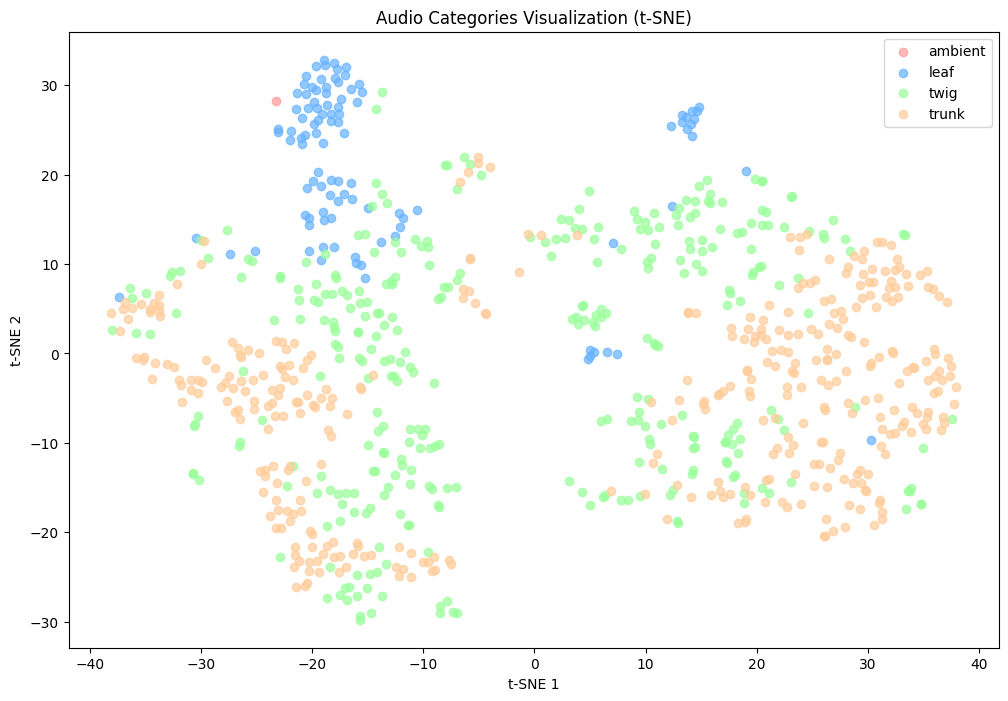

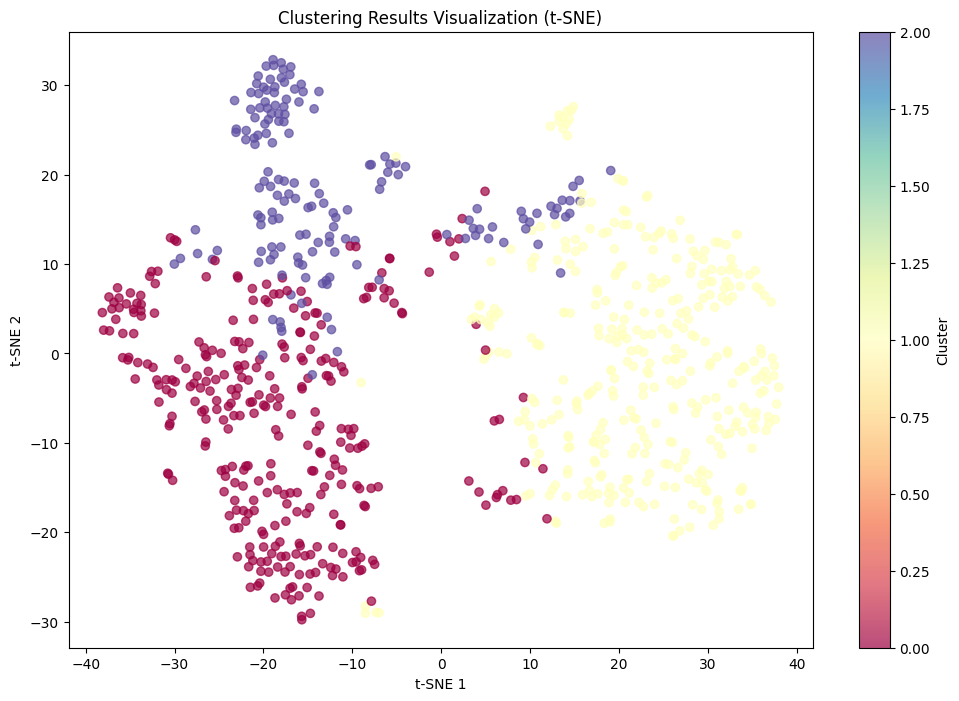

In [4]:
# Add t-SNE analysis
from sklearn.manifold import TSNE
import time

# Perform t-SNE
print("Performing t-SNE...")
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
print(f"t-SNE completed in {time.time() - start_time:.2f} seconds")

# Create plot
plt.figure(figsize=(12, 8))

# Plot each category with different colors
for category, color in zip(categories, colors):
    mask = y == category
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
               label=category, alpha=0.7, c=color)

plt.title('Audio Categories Visualization (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.show()

# Also create a plot showing the clustering results
plt.figure(figsize=(12, 8))




scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                     c=cluster_labels, cmap='Spectral',
                     alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('Clustering Results Visualization (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

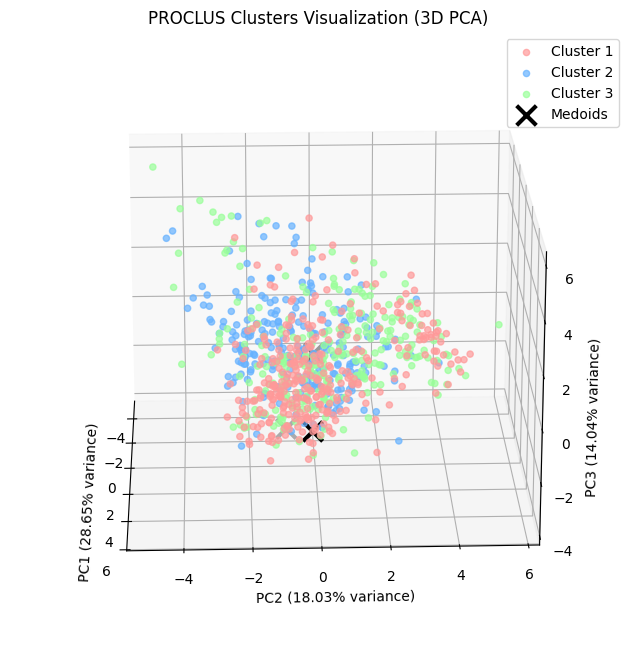


Cluster 1:
Number of points: 320
Relevant dimensions: [10  6 14 13 16]

Cluster 2:
Number of points: 247
Relevant dimensions: [11  5 13  3 14]

Cluster 3:
Number of points: 264
Relevant dimensions: [ 9 16 11 15  4]


In [5]:
import numpy as np
from matplotlib.animation import FuncAnimation
import random
from scipy.spatial.distance import euclidean

class PROCLUS:
    def __init__(self, k, l, min_dev_fraction=0.1, termination_rounds=3):
        self.k = k  # number of clusters
        self.l = l  # average number of dimensions per cluster
        self.min_dev_fraction = min_dev_fraction
        self.termination_rounds = termination_rounds
        
    def _find_medoids(self, X, k):
        n_samples = X.shape[0]
        # Randomly select k medoids
        medoid_indices = random.sample(range(n_samples), k)
        return medoid_indices
    
    def _compute_dimensions(self, X, medoid_idx, neighbors):
        dimensions = []
        X_neighbors = X[neighbors]
        
        # Calculate variance along each dimension
        variances = np.var(X_neighbors, axis=0)
        
        # Select dimensions with highest variance
        selected_dims = np.argsort(variances)[-self.l:]
        return selected_dims
    
    def fit(self, X):
        self.medoid_indices = self._find_medoids(X, self.k)
        self.medoids = X[self.medoid_indices]
        self.dimensions = []
        
        # Find relevant dimensions for each medoid
        for medoid_idx in self.medoid_indices:
            # Find nearest neighbors
            distances = [euclidean(X[medoid_idx], x) for x in X]
            neighbors = np.argsort(distances)[:10]  # Use 10 nearest neighbors
            
            # Compute relevant dimensions
            dims = self._compute_dimensions(X, medoid_idx, neighbors)
            self.dimensions.append(dims)
        
        # Assign points to clusters
        self.labels_ = self._assign_clusters(X)
        return self
    
    def _assign_clusters(self, X):
        labels = np.zeros(len(X), dtype=int)
        
        for i, point in enumerate(X):
            min_dist = float('inf')
            best_cluster = 0
            
            # Find closest medoid considering relevant dimensions
            for j, (medoid, dims) in enumerate(zip(self.medoids, self.dimensions)):
                # Only consider relevant dimensions for distance calculation
                dist = np.sqrt(np.mean((point[dims] - medoid[dims])**2))
                if dist < min_dist:
                    min_dist = dist


                    best_cluster = j
            
            labels[i] = best_cluster
        
        return labels


# Apply PROCLUS
proclus = PROCLUS(k=3, l=5)  # 3 clusters, 5 dimensions per cluster
proclus.fit(X_scaled)
cluster_labels = proclus.labels_

# Create 3D visualization using PCA for dimensionality reduction
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot points colored by cluster
colors = ['#FF9999', '#66B2FF', '#99FF99']  # One color per cluster
for i in range(proclus.k):
    mask = cluster_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2], 
              label=f'Cluster {i+1}', alpha=0.7, c=colors[i])

# Plot medoids
medoids_pca = pca.transform(proclus.medoids)
ax.scatter(medoids_pca[:, 0], medoids_pca[:, 1], medoids_pca[:, 2], 
          c='black', marker='x', s=200, linewidth=3, label='Medoids')

# Labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('PROCLUS Clusters Visualization (3D PCA)')
plt.legend()

# Animation function
def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

# Create and save animation
anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), 
                    interval=50, blit=True)
anim.save('3d_proclus_clusters_rotation.gif', writer='pillow')

plt.show()

# Print information about the clusters and their relevant dimensions
for i in range(proclus.k):
    print(f"\nCluster {i+1}:")
    print(f"Number of points: {np.sum(cluster_labels == i)}")
    
    print("Relevant dimensions:", proclus.dimensions[i])

Number of clusters: 0
Number of noise points: 236

eps=0.3:
Number of clusters: 0
Number of noise points: 236

eps=0.5:
Number of clusters: 0
Number of noise points: 236

eps=1.0:
Number of clusters: 0
Number of noise points: 236


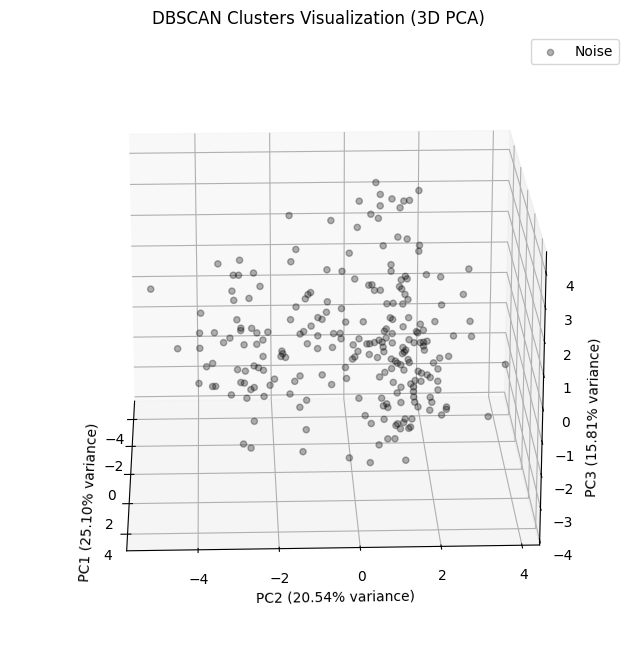


Noise points:
Size: 236 samples (100.0% of total)


In [6]:
 from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust these parameters as needed
cluster_labels = dbscan.fit_predict(X_scaled)

# Get number of clusters (excluding noise points labeled as -1)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')
# Optional: Test different eps values
eps_range = [0.3, 0.5, 1.0]
for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f'\neps={eps}:')
    print(f'Number of clusters: {n_clusters}')
    print(f'Number of noise points: {n_noise}')
# Create 3D visualization using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Generate colors for clusters
colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))
# Add black for noise points
colors = np.vstack((np.array([0, 0, 0, 1]), colors))  

# Plot points
for i in range(-1, n_clusters):  # -1 is for noise points
    mask = cluster_labels == i
    if i == -1:
        label = 'Noise'
        color = colors[0]
        alpha = 0.3
    else:
        label = f'Cluster {i+1}'
        color = colors[i+1]
        alpha = 0.7
        
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2], 
              label=label, alpha=alpha, c=[color])

# Labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('DBSCAN Clusters Visualization (3D PCA)')
plt.legend()

# Animation function
def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

# Create and save animation
anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), 
                    interval=50, blit=True)
anim.save('3d_dbscan_clusters_rotation.gif', writer='pillow')

plt.show()

# Print cluster statistics
for i in range(-1, n_clusters):
    cluster_mask = cluster_labels == i
    cluster_size = np.sum(cluster_mask)
    cluster_percentage = (cluster_size / len(X_scaled)) * 100
    
    if i == -1:
        print(f"\nNoise points:")
    else:
        print(f"\nCluster {i+1}:")
    print(f"Size: {cluster_size} samples ({cluster_percentage:.1f}% of total)")
    
    if i != -1:  # Skip category distribution for noise points
        print("\nCategory distribution:")
        for category in categories:
            category_count = np.sum((y == category) & cluster_mask)
            if cluster_size > 0:
                category_percentage = (category_count / cluster_size) * 100
                print(f"{category}: {category_count} samples ({category_percentage:.1f}%)")

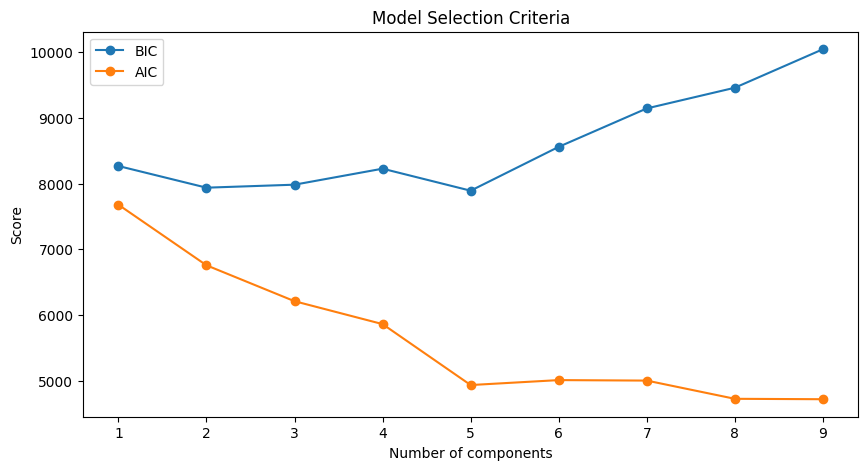

Optimal number of components: 5


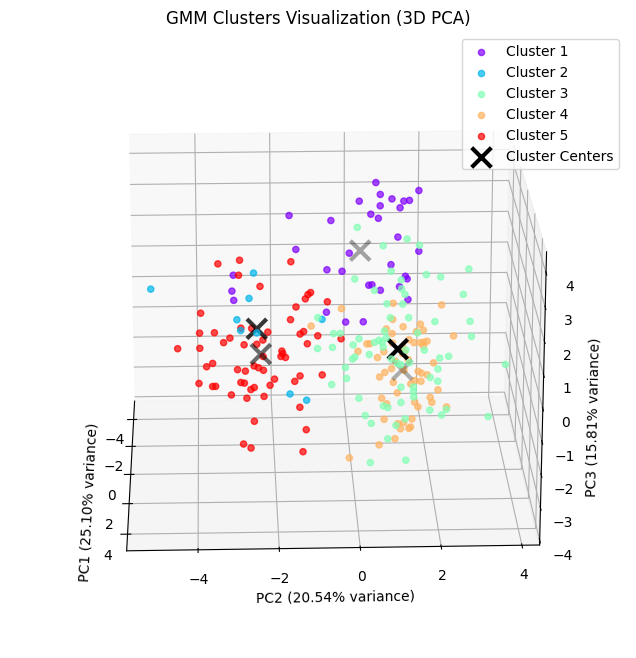


Cluster Statistics:

Cluster 1:
Size: 33 samples (14.0% of total)

Category distribution:
ambient: 0 samples (0.0%)
leaf: 4 samples (12.1%)
twig: 17 samples (51.5%)
trunk: 12 samples (36.4%)

Cluster characteristics:
Covariance type: full
Average probability of cluster membership: 0.140

Cluster 2:
Size: 9 samples (3.8% of total)

Category distribution:
ambient: 0 samples (0.0%)
leaf: 6 samples (66.7%)
twig: 3 samples (33.3%)
trunk: 0 samples (0.0%)

Cluster characteristics:
Covariance type: full
Average probability of cluster membership: 0.038

Cluster 3:
Size: 72 samples (30.5% of total)

Category distribution:
ambient: 1 samples (1.4%)
leaf: 68 samples (94.4%)
twig: 3 samples (4.2%)
trunk: 0 samples (0.0%)

Cluster characteristics:
Covariance type: full
Average probability of cluster membership: 0.305

Cluster 4:
Size: 60 samples (25.4% of total)

Category distribution:
ambient: 0 samples (0.0%)
leaf: 0 samples (0.0%)
twig: 29 samples (48.3%)
trunk: 31 samples (51.7%)

Cluster char

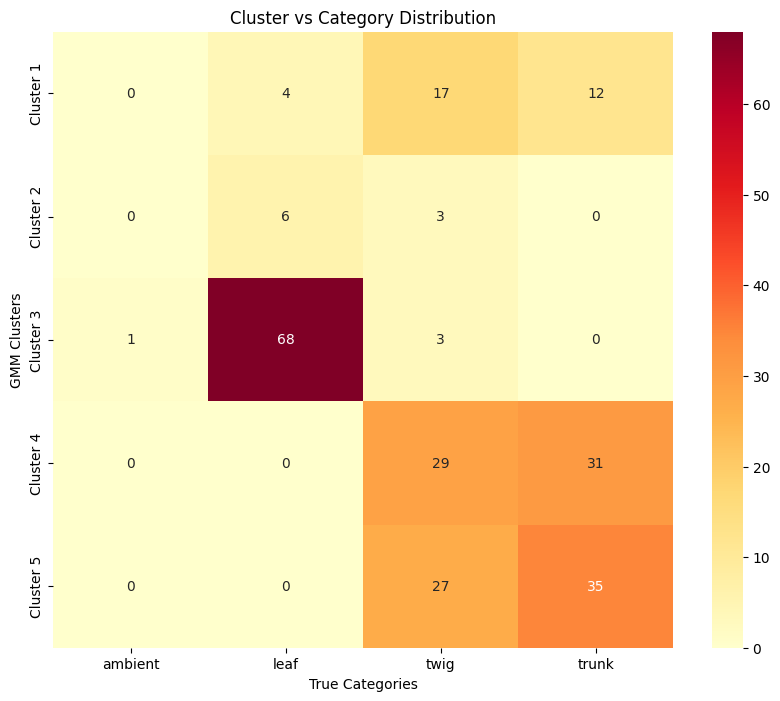


Clustering Evaluation Metrics:
Cluster Purity: 0.665
Normalized Mutual Information: 0.411
Adjusted Rand Index: 0.368

Detailed Cluster Composition:

Cluster 1:
ambient: 0 samples (0.0%)
leaf: 4 samples (12.1%)
twig: 17 samples (51.5%)
trunk: 12 samples (36.4%)

Cluster 2:
ambient: 0 samples (0.0%)
leaf: 6 samples (66.7%)
twig: 3 samples (33.3%)
trunk: 0 samples (0.0%)

Cluster 3:
ambient: 1 samples (1.4%)
leaf: 68 samples (94.4%)
twig: 3 samples (4.2%)
trunk: 0 samples (0.0%)

Cluster 4:
ambient: 0 samples (0.0%)
leaf: 0 samples (0.0%)
twig: 29 samples (48.3%)
trunk: 31 samples (51.7%)

Cluster 5:
ambient: 0 samples (0.0%)
leaf: 0 samples (0.0%)
twig: 27 samples (43.5%)
trunk: 35 samples (56.5%)


In [7]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA

# Try different numbers of components and compare BIC scores
n_components_range = range(1, 10)
bic = []
aic = []

for n_components in n_components_range:
    # Fit GMM
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X_scaled)
    
    # Calculate scores
    bic.append(gmm.bic(X_scaled))
    aic.append(gmm.aic(X_scaled))

# Plot BIC and AIC scores
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bic, label='BIC', marker='o')
plt.plot(n_components_range, aic, label='AIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('Score')
plt.title('Model Selection Criteria')
plt.legend()
plt.show()

# Choose optimal number of components (lowest BIC score)
optimal_n_components = n_components_range[np.argmin(bic)]
print(f"Optimal number of components: {optimal_n_components}")

# Fit GMM with optimal components
gmm = GaussianMixture(n_components=optimal_n_components, random_state=42)
gmm.fit(X_scaled)
cluster_labels = gmm.predict(X_scaled)
cluster_probs = gmm.predict_proba(X_scaled)

# Create 3D visualization using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Generate colors for clusters
colors = plt.cm.rainbow(np.linspace(0, 1, optimal_n_components))

# Plot points
for i in range(optimal_n_components):
    mask = cluster_labels == i
    
    # Get probability of belonging to this cluster
    probs = cluster_probs[:, i]
    points = X_pca[mask]
    
    scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                        c=[colors[i]], 
                        alpha=0.7,
                        label=f'Cluster {i+1}')

# Plot cluster centers
centers_pca = pca.transform(gmm.means_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], centers_pca[:, 2],
          c='black', marker='x', s=200, linewidth=3,
          label='Cluster Centers')

# Labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('GMM Clusters Visualization (3D PCA)')
plt.legend()

# Animation function
def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

# Create and save animation
anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2),
                    interval=50, blit=True)
anim.save('3d_gmm_clusters_rotation.gif', writer='pillow')

plt.show()

# Print cluster statistics and analysis
print("\nCluster Statistics:")
for i in range(optimal_n_components):
    cluster_mask = cluster_labels == i
    cluster_size = np.sum(cluster_mask)
    cluster_percentage = (cluster_size / len(X_scaled)) * 100
    
    print(f"\nCluster {i+1}:")
    print(f"Size: {cluster_size} samples ({cluster_percentage:.1f}% of total)")
    
    # Category distribution within cluster
    print("\nCategory distribution:")
    for category in categories:
        category_count = np.sum((y == category) & cluster_mask)
        if cluster_size > 0:
            category_percentage = (category_count / cluster_size) * 100
            print(f"{category}: {category_count} samples ({category_percentage:.1f}%)")
    
    # Cluster characteristics
    print("\nCluster characteristics:")
    print(f"Covariance type: {gmm.covariance_type}")
    print(f"Average probability of cluster membership: {np.mean(cluster_probs[:, i]):.3f}")

# Print overall model information
print("\nModel Information:")
print(f"Log-likelihood: {gmm.score(X_scaled):.2f}")
print(f"BIC: {gmm.bic(X_scaled):.2f}")
print(f"AIC: {gmm.aic(X_scaled):.2f}")

# Create confusion matrix / contingency table
plt.figure(figsize=(10, 8))
confusion_matrix = np.zeros((optimal_n_components, len(categories)))

for i in range(optimal_n_components):
    for j, category in enumerate(categories):
        confusion_matrix[i, j] = np.sum((cluster_labels == i) & (y == category))

# Plot heatmap
sns.heatmap(confusion_matrix, 
            xticklabels=categories,
            yticklabels=[f'Cluster {i+1}' for i in range(optimal_n_components)],
            annot=True, 
            fmt='g',
            cmap='YlOrRd')
plt.title('Cluster vs Category Distribution')
plt.xlabel('True Categories')
plt.ylabel('GMM Clusters')
plt.show()

# Calculate and print clustering metrics
print("\nClustering Evaluation Metrics:")

# Calculate purity
purity = np.sum(np.max(confusion_matrix, axis=1)) / np.sum(confusion_matrix)
print(f"Cluster Purity: {purity:.3f}")

# Calculate normalized mutual information (NMI)
from sklearn.metrics import normalized_mutual_info_score
nmi = normalized_mutual_info_score(y, cluster_labels)
print(f"Normalized Mutual Information: {nmi:.3f}")

# Calculate adjusted rand index
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Index: {ari:.3f}")

# Print detailed cluster composition
print("\nDetailed Cluster Composition:")
for i in range(optimal_n_components):
    print(f"\nCluster {i+1}:")
    total_in_cluster = np.sum(confusion_matrix[i])
    for j, category in enumerate(categories):
        count = confusion_matrix[i, j]
        percentage = (count / total_in_cluster * 100) if total_in_cluster > 0 else 0
        print(f"{category}: {int(count)} samples ({percentage:.1f}%)")